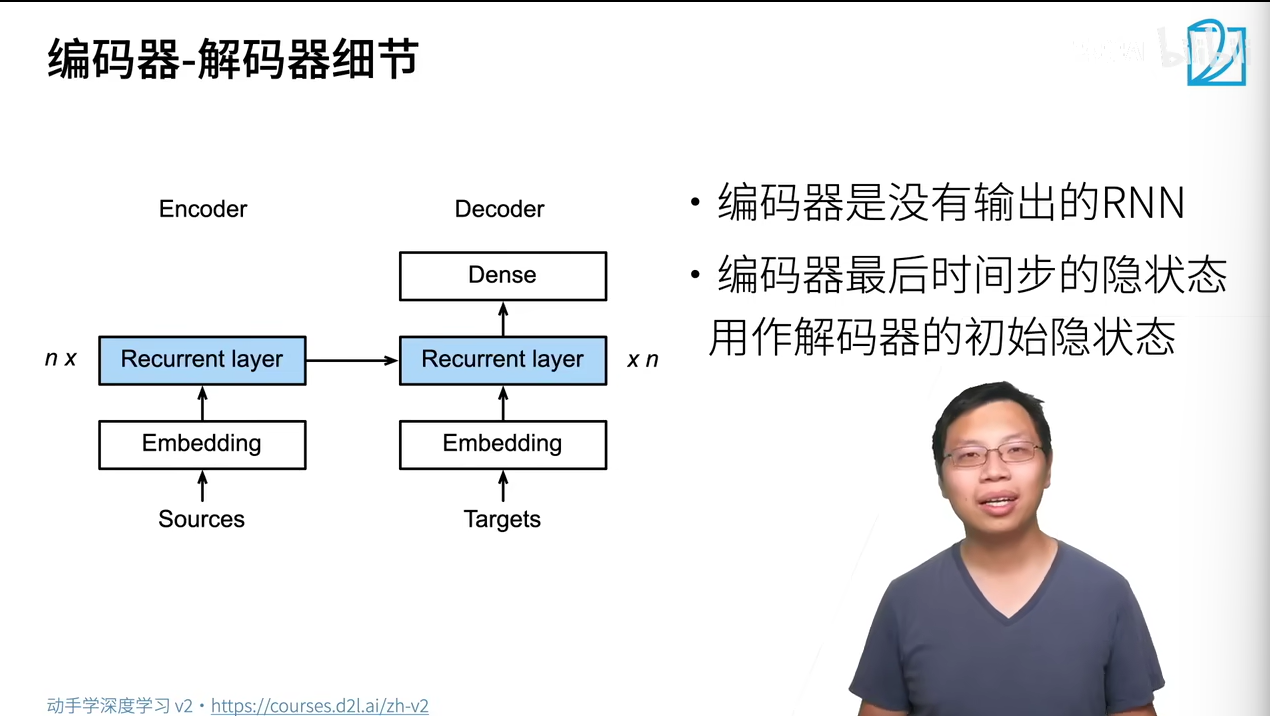
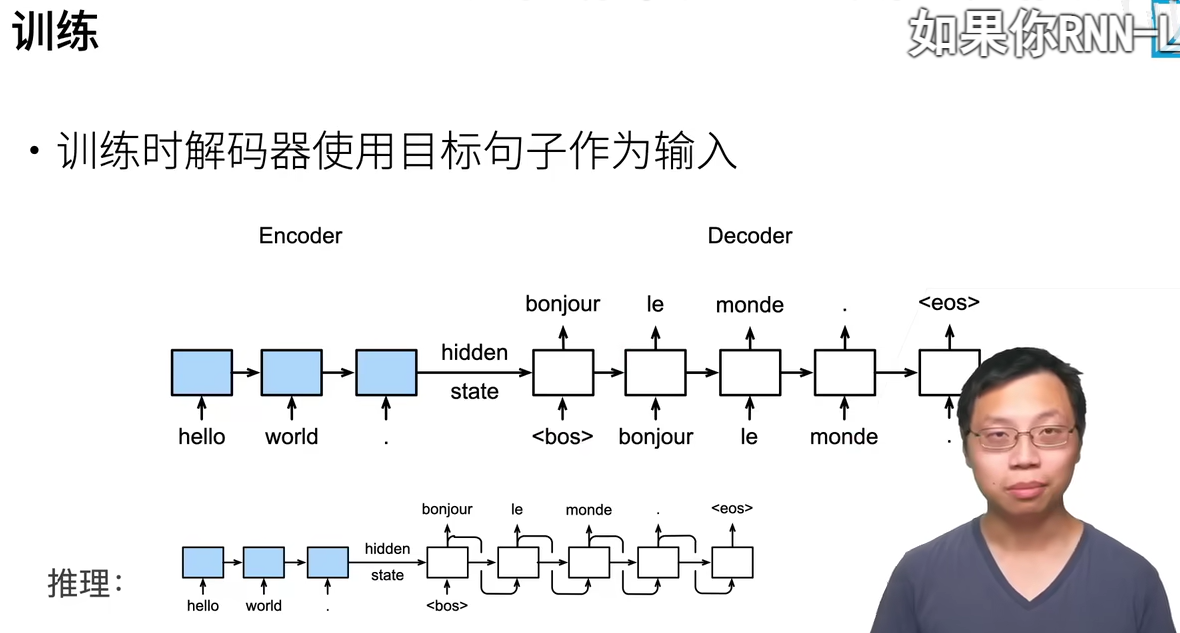

评价指标
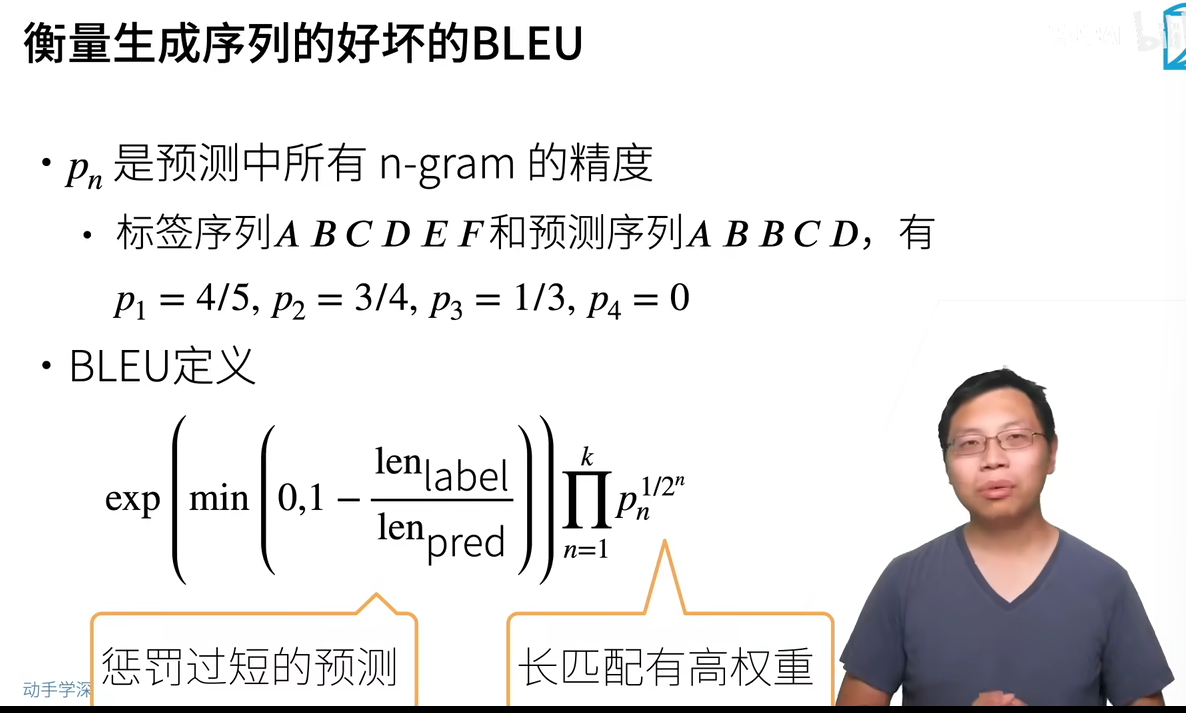

p_i = 长度为i的标签的匹配概率
p_1 = 4/5 （==A,B,C,D都匹配了，生成序列的长度为1的标签一共有5个，4个匹配上了故为 4/5）
p_2 = 3/4  (== 生成序列中长度为2的标签有AB,BB,BC,CD,其中AB,BC,CD都匹配上了，故为3/4)

BLEU公式详解：
首先，判断生成序列和原序列的长度大小，当生成序列长度小于原序列时，1-len_label/len_pred>0,我们取0代替这个值；当生成序列长度大于原序列时，1-len_label/len_pred<0,保留。（原因，越短越容易命中精度，例如预测的是A,就很容易命中，所以需要惩罚过短的句子，生成序列相对于原序列越短（通过比值），惩罚项就越重）

长匹配的高权重 ：∑p_n **(1/2* *n)
对于p_n,值域处于0-1之间;
n为1-+∞之间的整数;
n越大，2**n越大，1/(2* *n)越小，且处于0-1之间。
对于一个小于1且大于0的底数，指数处于0-1之间时，指数的值越小，那么结果越大，即长度更长的生成序列权重更大。

In [ ]:
#编码器设置：
import torch 
import torch.nn as nn

class Seq2SeqEncoder(nn.Module):
    def __init__(self,vocab_size,embed_size,num_hiddens,num_layers,dropout):
       super().__init__()
       #1.嵌入层:把离散词索引映射为连续向量
       self.embedding=nn.Embedding(vocab_size,embed_size)
       #2.多层GRU循环
       self.rnn = nn.GRU(embed_size,num_hiddens,num_layers,dropout=dropout)

    def forward(self,X):
        #输入X的形状:(batch_size,num_steps)
        #经过embeding变为(batch_size,num_steps,embed_size)
        embs=self.embedding(X)
        #pytorch的RNN要求输入的形状为(num_steps,batch_size,embed_size)
        embs=embs.permute(1,0,2)
        #输出output的形状:(num_steps,batch_size,num_hiddens)
        #输出state的形状:(num_layers,batch_size,num_hiddens)   
        output,state=self.rnn(embs)
        return output,state 


# ============ 快速测试 Encoder 形状 ============
encoder = Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2,dropout=0.1)
encoder.eval()
X = torch.zeros((4, 7), dtype=torch.long) # Batch=4, 句子长度=7
outputs, state = encoder(X)
print("Encoder outputs shape (预期 [7, 4, 16]):", outputs.shape)
print("Encoder state shape   (预期 [2, 4, 16]):", state.shape)

Encoder outputs shape (预期 [7, 4, 16]): torch.Size([7, 4, 16])
Encoder state shape   (预期 [2, 4, 16]): torch.Size([2, 4, 16])


In [ ]:
class Seq2SeqDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 输入维度是 embed_size + num_hiddens (因为拼接了上下文向量 context)
        self.rnn = nn.GRU(embed_size + num_hiddens, num_hiddens, num_layers, dropout=dropout)
        # 分类头：映射到目标语言词表大小
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_state):
        # 直接拿编码器的最终隐状态作为解码器的初始状态
        return enc_state

    def forward(self, X, state):
        # X 形状: [batch_size, num_steps]
        # state 形状: [num_layers, batch_size, num_hiddens]
        embs = self.embedding(X).permute(1, 0, 2) # [num_steps, batch_size, embed_size]
        
        # 提取编码器最高层的最终状态作为上下文广播
        # state[-1] 形状为 [batch_size, num_hiddens]
        # 重复 num_steps 次，构造形状为 [num_steps, batch_size, num_hiddens] 的 context
        context = state[-1].repeat(embs.shape[0], 1, 1)
        
        # 沿特征维度拼接: [num_steps, batch_size, embed_size + num_hiddens]
        embs_and_context = torch.cat((embs, context), dim=2)
        
        # 过解码器 GRU
        outputs, state = self.rnn(embs_and_context, state)
        
        # 通过全连接分类头映射到词表大小
        # outputs 形状: [num_steps, batch_size, num_hiddens] -> [num_steps, batch_size, vocab_size]
        # 置换回 [batch_size, num_steps, vocab_size]
        outputs = self.dense(outputs).permute(1, 0, 2)
        return outputs, state

# ============ 快速测试 Decoder 形状 ============
decoder = Seq2SeqDecoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)
decoder.eval()
dec_state = decoder.init_state(outputs, state)
Y = torch.zeros((4, 5), dtype=torch.long) # Batch=4, 目标长度=5
dec_outputs, dec_state = decoder(Y, dec_state)
print("Decoder outputs shape (预期 [4, 5, 10]):", dec_outputs.shape)
print("Decoder state shape   (预期 [2, 4, 16]):", dec_state.shape)

Decoder outputs shape (预期 [4, 5, 10]): torch.Size([4, 5, 10])
Decoder state shape   (预期 [2, 4, 16]): torch.Size([2, 4, 16])


In [ ]:
def sequence_mask(X, valid_len, value=0):
    """在序列中屏蔽不相关的项（把 padding 区域置为 0）"""
    maxlen = X.size(1)
    mask = torch.arange(maxlen, dtype=torch.float32, device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """带掩码的交叉熵损失函数"""
    def forward(self, pred, label, valid_len):
        # pred 形状: [batch_size, num_steps, vocab_size]
        # label 形状: [batch_size, num_steps]
        # valid_len: [batch_size] 记录每个样本真实的有效词数
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valid_len) # 把 padding 位置的权重置为 0
        
        self.reduction = 'none'
        # 交叉熵需要预测维度在第 1 维: [batch_size, vocab_size, num_steps]
        unweighted_loss = super().forward(pred.permute(0, 2, 1), label)
        # 乘上掩码权重，在有效词上取平均
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

In [ ]:
class EncoderDecoder(nn.Module):
    """编码器-解码器顶层封装"""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X):
        enc_outputs, enc_state = self.encoder(enc_X)
        dec_state = self.decoder.init_state(enc_outputs, enc_state)
        return self.decoder(dec_X, dec_state)

def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """训练 Seq2Seq 模型的完整流程"""
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    
    for epoch in range(num_epochs):
        total_loss = 0.0
        num_tokens = 0
        for batch in data_iter:
            optimizer.zero_grad()
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            
            # 【Teacher Forcing 核心切片】
            # dec_input 作为输入: [<bos>, y_1, y_2, ...]
            dec_input = torch.cat([torch.tensor([tgt_vocab['<bos>']] * Y.shape[0], device=device).unsqueeze(1), 
                                   Y[:, :-1]], dim=1)
            
            # 前向计算
            Y_hat, _ = net(X, dec_input)
            
            # 计算有效长度下的 Loss (标签为 Y 自身)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()
            
            # 梯度裁剪 (防止 RNN 梯度爆炸)
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1)
            
            optimizer.step()
            total_loss += l.sum().item()
            num_tokens += Y_valid_len.sum().item()
            
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d} | Loss: {total_loss / num_tokens:.4f}")

In [ ]:
import collections
import math

def predict_seq2seq(net, src_sentence_tokens, src_vocab, tgt_vocab, num_steps, device):
    """自回归推理生成翻译结果"""
    net.eval()
    # 构造编码器输入
    src_tokens = [src_vocab[tok] for tok in src_sentence_tokens] + [src_vocab['<eos>']]
    enc_valid_len = torch.tensor([len(src_tokens)], device=device)
    # 填充到固定长度
    if len(src_tokens) < num_steps:
        src_tokens += [src_vocab['<pad>']] * (num_steps - len(src_tokens))
    enc_X = torch.tensor(src_tokens, dtype=torch.long, device=device).unsqueeze(0)
    
    # 1. 编码器前向计算
    enc_outputs, enc_state = net.encoder(enc_X)
    dec_state = net.decoder.init_state(enc_outputs, enc_state)
    
    # 2. 解码器起始输入 <bos>
    dec_X = torch.tensor([tgt_vocab['<bos>']], dtype=torch.long, device=device).unsqueeze(0)
    output_seq = []
    
    # 3. 自回归循环
    for _ in range(num_steps):
        Y, dec_state = net.decoder(dec_X, dec_state)
        # 取当前步概率最大的词索引
        pred_token_id = Y.argmax(dim=2).item()
        # 如果生成了 <eos>，提前终止
        if pred_token_id == tgt_vocab['<eos>']:
            break
        output_seq.append(tgt_vocab.to_tokens(pred_token_id))
        # 将当前生成的词作为下一步的输入
        dec_X = torch.tensor([[pred_token_id]], dtype=torch.long, device=device)
        
    return ' '.join(output_seq)

def bleu(pred_seq, label_seq, k=4):
    """实现你在笔记中总结的 BLEU 评价公式"""
    pred_tokens, label_tokens = pred_seq.split(' '), label_seq.split(' ')
    len_pred, len_label = len(pred_tokens), len(label_tokens)
    
    # 1. 短句惩罚项 (Brevity Penalty)
    score = math.exp(min(0, 1 - len_label / len_pred))
    
    # 2. n-gram 匹配连乘
    for n in range(1, min(k, len_pred) + 1):
        num_matches = 0
        label_subs = collections.defaultdict(int)
        for i in range(len_label - n + 1):
            label_subs[' '.join(label_tokens[i: i + n])] += 1
        for i in range(len_pred - n + 1):
            sub = ' '.join(pred_tokens[i: i + n])
            if label_subs[sub] > 0:
                num_matches += 1
                label_subs[sub] -= 1
        # p_n 精度
        p_n = num_matches / (len_pred - n + 1)
        # 加权连乘 p_n ** (1 / 2^n)
        score *= math.pow(p_n, math.pow(0.5, n))
    return score